# 02 — Trajectory Critic

**Sub-problem B · Project 23 · Punith KM**

Builds the feature-based critic: given one step of an agent run, predict whether
the run is heading for a wrong answer.

Input is `data/critic/labelled_steps.parquet`, produced by
`scripts/label_dataset.py`. Labelling is fixed and lives in a script; everything
from here — exploration, feature engineering, model selection — is done in the
open so the choices can be argued with.

### Contents

1. Load and inspect
2. Exploratory analysis
3. Choosing the target (and why the obvious one is wrong)
4. Feature engineering
5. Grouped split, frozen
6. Model comparison
7. Hyperparameter tuning
8. Operating threshold
9. Test set — scored once
10. What the model uses
11. Save

In [2]:
import json, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 140)

ROOT = Path("..") if (Path("../data")).exists() else Path(".")
sys.path.insert(0, str(ROOT.resolve()))

df = pd.read_parquet(ROOT / "data" / "critic" / "labelled_steps.parquet")
print(f"{len(df):,} steps · {df.run_id.nunique():,} runs · {df.task_id.nunique()} questions")
df.head(3)

5,461 steps · 1,620 runs · 120 questions


,run_id,task_id,step_index,label_step,y_run_fails,run_correct,label_execution,question,thought,tool,...,is_retry,schema_inspected_before,tokens_in_prompt,duration_ms,termination,run_total_steps,correct_method,model_name,temperature,context_policy
0,r-fac6597c,t001,0,0.5,0.0,True,error,What is the id and last name of the driver who...,"To answer this question, I need to find the dr...",run_sql,...,False,False,1120,9058,final_answer,3,execution,qwen2.5-coder:3b,0.7,full_history
1,r-fac6597c,t001,1,1.0,0.0,True,ok,What is the id and last name of the driver who...,The error indicates that the SQL function `YEA...,run_sql,...,False,False,1238,4739,final_answer,3,execution,qwen2.5-coder:3b,0.7,full_history
2,r-fac6597c,t001,2,1.0,0.0,True,NaN,What is the id and last name of the driver who...,The tool returned a single row with the driver...,final_answer,...,False,False,1347,4185,final_answer,3,execution,qwen2.5-coder:3b,0.7,full_history


In [5]:
df.columns

Index(['run_id', 'task_id', 'step_index', 'label_step', 'y_run_fails', 'run_correct', 'label_execution', 'question', 'thought', 'tool',
       'sql', 'args', 'status', 'raw_model_output', 'obs_status', 'obs_rows', 'obs_truncated', 'obs_error', 'error_category',
       'consecutive_errors', 'total_errors_so_far', 'parse_repair_count', 'repeat_count', 'is_retry', 'schema_inspected_before',
       'tokens_in_prompt', 'duration_ms', 'termination', 'run_total_steps', 'correct_method', 'model_name', 'temperature',
       'context_policy'],
      dtype='str')

# Data dictionary — `labelled_steps.parquet`

One row per agent step. 5,461 rows, 33 columns, produced by
`scripts/label_dataset.py`.

Each column is marked:

- **KEY** — identifier, never a feature
- **TARGET** — what we predict, never a feature
- **FEATURE** — safe to use as model input
- **TEXT** — raw text, for the ModernBERT critic later
- **META** — provenance and diagnostics, not a feature
- **LEAK** — looks usable but must not be used, with the reason

---

## Identifiers

| Column | Type | Contains | Use |
|---|---|---|---|
| `run_id` | str | Unique id for one attempt at one question, e.g. `r-4a2f91c3`. All steps of a run share it. | **KEY** — used to group the train/test split |
| `task_id` | str | Which question, e.g. `t047`. Maps to `data/tasks/task_suite.json`. | **KEY** |
| `step_index` | int | Position in the run, starting at 0. | **FEATURE** |

`run_id` is what makes the split honest — every step of a run goes to the same
side, otherwise the model sees near-duplicate rows across the boundary.

---

## Targets

| Column | Type | Contains | Use |
|---|---|---|---|
| `label_step` | float | 0.0 bad · 0.5 exploratory · 1.0 good. From our rules in `agent/labeller.py`. `None` if the run was unscoreable. | **TARGET** — but see the warning below |
| `y_run_fails` | int | 1 if this run ended with a wrong answer, 0 if correct, `None` if unscoreable. From comparing against gold SQL. | **TARGET** — the one we use |
| `run_correct` | bool | Same information as `y_run_fails`, inverted. | **TARGET** |
| `label_execution` | str | `ok` / `error` / `empty` — what the tool did. | **TARGET-ish**, also a diagnostic |

### Why `y_run_fails` and not `label_step`

`label_step` is assigned by rules that read the step's own fields:

```python
if step.repeat_count >= 2:  return BAD
if run failed and step errored:  return BAD
```

Measured: **93% of `label_step` is reproducible from fields the model would also
receive**. Training on it mostly relearns the rule, and the score is meaningless.

`y_run_fails` comes from running the gold SQL and comparing result sets. Nothing
in the step features can produce it.

---

## What the agent did — text

| Column | Type | Contains | Use |
|---|---|---|---|
| `question` | str | The user's question in natural language. Identical across all steps of a run. | **TEXT** |
| `thought` | str | The model's stated reasoning for this step. | **TEXT** — length is a FEATURE |
| `sql` | str | The SQL query, if this step called `run_sql`. Empty otherwise. | **TEXT** — derived shape features below |
| `args` | str | The full action arguments as a string, for any tool. | **TEXT** |
| `raw_model_output` | str | The model's unparsed reply. Kept for debugging the parser. | **META** |
| `tool` | str | Which action was taken: `run_sql`, `get_schema`, `python_repl`, `final_answer`, or `None` on a parse failure. | **FEATURE** (categorical) |
| `status` | str | `continue`, `error`, `final`, or `terminated`. | **FEATURE** (as `is_error`) |

---

## What came back

| Column | Type | Contains | Use |
|---|---|---|---|
| `obs_status` | str | `ok` or `error` from the tool. `None` if no tool ran. | **FEATURE** |
| `obs_rows` | float | True row count *before* truncation. `None` if not a query. | **FEATURE** |
| `obs_truncated` | bool | Whether the tool cut the result to 20 rows. | **FEATURE** |
| `obs_error` | str | Short error message. `None` on success. | **TEXT** |
| `error_category` | str | Structured error type: `none`, `schema_missing_column`, `syntax`, `empty_result`, `runtime`, `timeout`, `permission`, `unknown_tool`, `invalid_args`, `other`. | **FEATURE** (categorical) |

`obs_rows` is genuinely informative: a query returning 0 rows often means a
filter is wrong, and one returning 3,000 often means the aggregation is missing.

---

## Counters, as at this step

These were computed by the loop *at the moment the step ran*, so they contain no
information from later steps.

| Column | Type | Contains | Use |
|---|---|---|---|
| `consecutive_errors` | int | Errors in an unbroken sequence up to here. Resets on success. | **FEATURE** |
| `total_errors_so_far` | int | All errors in this run up to and including this step. | **FEATURE** |
| `parse_repair_count` | int | Times the parser had to ask the model to fix its output. | **FEATURE** |
| `repeat_count` | int | How many times this exact action (tool + normalised args) has been issued in this run. | **LEAK** — see below |
| `is_retry` | bool | Whether this step retries an earlier one. | **FEATURE** |
| `schema_inspected_before` | bool | Whether `get_schema` had succeeded *before* this step. False on the step that does the inspecting. | **FEATURE** |
| `tokens_in_prompt` | int | Prompt size at this step. Grows through the run. | **FEATURE** |
| `duration_ms` | int | Wall-clock time for this step. | **FEATURE** |

### Why `repeat_count` is excluded

The loop guard **terminates a run** when an action repeats three times. So a
high `repeat_count` doesn't predict failure — it *causes* the termination that
becomes the failure. Self-fulfilling.

Dropping it costs 0.001 PR-AUC, so there's no reason to keep it.

`schema_inspected_before` is worth noting: it describes state *before* the step,
so the `get_schema` step itself records `False`. Recording `True` would leak the
step's own outcome into its features.

---

## Run context

| Column | Type | Contains | Use |
|---|---|---|---|
| `termination` | str | How the run ended: `final_answer`, `repeated_action`, `parse_failure`, `consecutive_errors`, `max_iterations`, `token_budget`, `no_progress`, `tool_crash`, `critic_stop`. | **LEAK** — known only at the end |
| `run_total_steps` | int | How many steps the run had in total. | **LEAK** — at step 3 you don't know the run will last 7 |
| `correct_method` | str | How correctness was decided: `execution` (result sets compared, the Spider metric), `answer_match` (values found in the prose), or `none`. | **META** |

`termination` and `run_total_steps` are the two most tempting leaks in the
table. Both are only knowable after the run is over, and both correlate strongly
with failure — which is exactly what makes them dangerous.

---

## Provenance

Recorded so a change in results can be attributed to a cause rather than
guessed at.

| Column | Type | Contains | Use |
|---|---|---|---|
| `model_name` | str | `qwen2.5-coder:3b` | **META** — filter before training |
| `temperature` | float | 0.7 | **META** |
| `context_policy` | str | Agent configuration: schema mode, guard settings, step limit. | **META** — filter before training |

**Always check `context_policy.nunique() == 1` before training.** Runs from
different agent configurations have different failure distributions; mixing them
teaches the critic patterns that no longer occur.

---

## Summary

| Group | Columns | Model input? |
|---|---|---|
| Identifiers | 3 | only for grouping |
| Targets | 4 | no |
| Text | 5 | ModernBERT later; derived lengths now |
| Observation | 5 | yes |
| Counters | 8 | yes, except `repeat_count` |
| Run context | 3 | **no — leakage** |
| Provenance | 3 | no, but filter on them |

**25 engineered features** are built from these in the notebook. Three columns
are deliberately excluded despite looking useful: `repeat_count`,
`run_total_steps` and `termination`.


In [7]:
df.dtypes

run_id                         str
task_id                        str
step_index                   int64
label_step                 float64
y_run_fails                float64
run_correct                 object
label_execution                str
question                       str
thought                        str
tool                           str
sql                            str
args                           str
status                         str
raw_model_output               str
obs_status                     str
obs_rows                   float64
obs_truncated                 bool
obs_error                      str
error_category                 str
consecutive_errors           int64
total_errors_so_far          int64
parse_repair_count           int64
repeat_count                 int64
is_retry                      bool
schema_inspected_before       bool
tokens_in_prompt             int64
duration_ms                  int64
termination                    str
run_total_steps     

---
## 1. Load and inspect

First job: confirm every row came from the same agent. Mixing configurations
means mixing failure distributions, and the model would learn patterns that no
longer occur.

In [3]:
print("agent configurations present:")
for cfg, n in df.context_policy.value_counts().items():
    print(f"  {n:>5}  {cfg}")

print(f"\nmodel: {df.model_name.unique()}")
print(f"temperature: {df.temperature.unique()}")

assert df.context_policy.nunique() == 1, \
    "more than one config — filter before going further"

agent configurations present:
   5461  full_history

model: <ArrowStringArray>
['qwen2.5-coder:3b']
Length: 1, dtype: str
temperature: [0.7]


In [4]:
print("missing values:")
miss = df.isna().sum()
print(miss[miss > 0].to_string())

print(f"\nsteps per run: min {df.groupby('run_id').size().min()}, "
      f"median {df.groupby('run_id').size().median():.0f}, "
      f"max {df.groupby('run_id').size().max()}")

missing values:
label_step          229
y_run_fails         234
run_correct         234
label_execution    1560
tool                153
obs_status         1560
obs_rows           2403
obs_error          4628
correct_method       57

steps per run: min 1, median 3, max 12


In [5]:
df.duplicated("run_id").sum()

np.int64(3841)

---
## 2. Exploratory analysis

What do runs actually look like, and where do they go wrong?

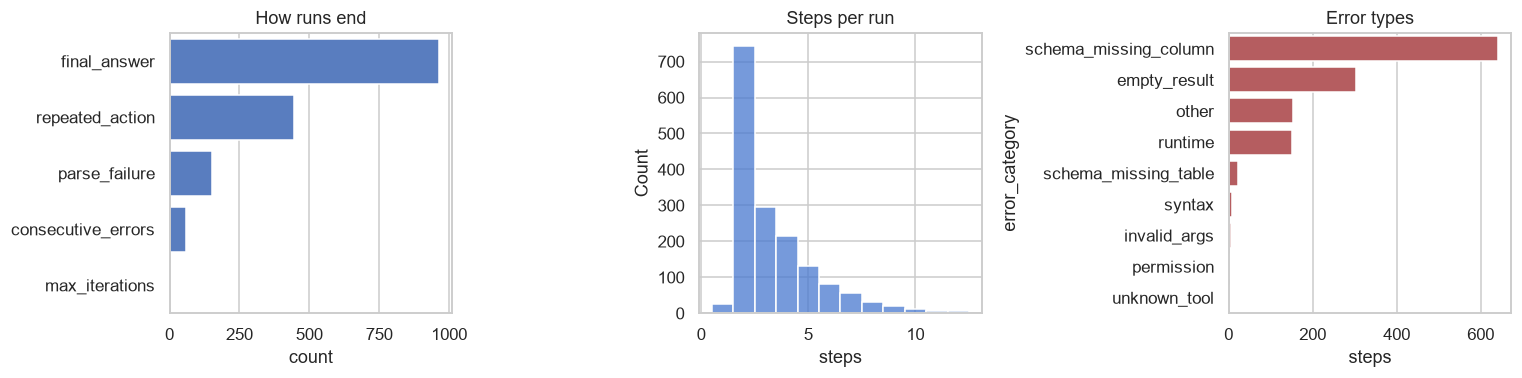

solve rate: 472/1620 = 29.1%


In [10]:
runs = df.drop_duplicates("run_id")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

sns.countplot(runs, y="termination", ax=axes[0],
              order=runs.termination.value_counts().index)
axes[0].set_title("How runs end"); axes[0].set_ylabel("")

sns.histplot(runs.run_total_steps, bins=range(1, 14), ax=axes[1], discrete=True)
axes[1].set_title("Steps per run"); axes[1].set_xlabel("steps")

ec = df[df.error_category != "none"].error_category.value_counts()
sns.barplot(x=ec.values, y=ec.index, ax=axes[2], color="#C44E52")
axes[2].set_title("Error types"); axes[2].set_xlabel("steps")

plt.tight_layout(); plt.show()

solved = runs.run_correct.eq(True).sum()
print(f"solve rate: {solved}/{len(runs)} = {solved/len(runs):.1%}")

### Does the outcome show up early?

If failing runs only look different at the last step, a critic is useless — by
then the compute is already spent. The question is whether step 0 or step 1
already carries signal.

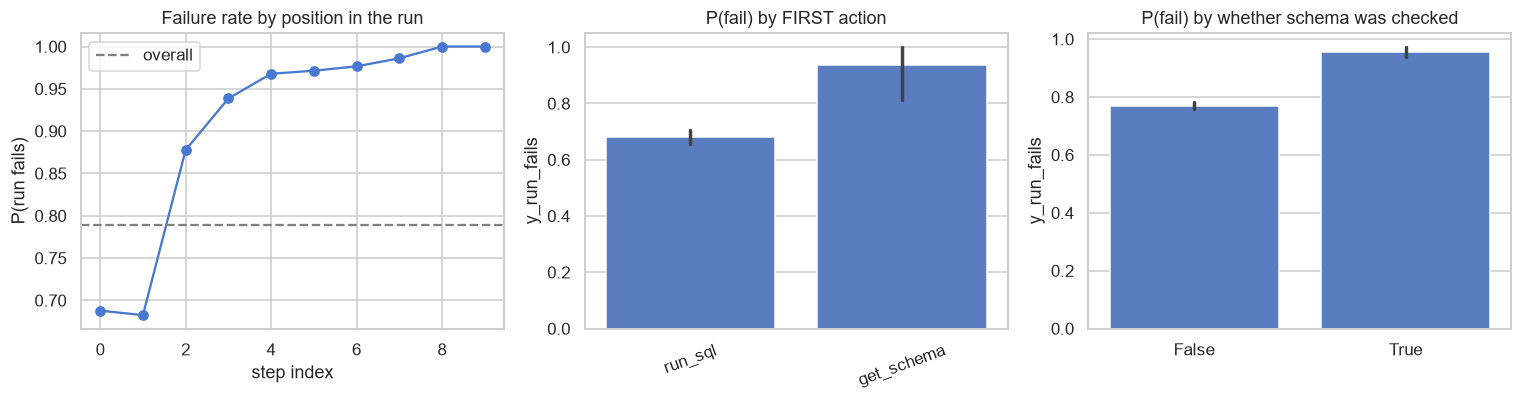

In [11]:
d = df[df.y_run_fails.notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

by_step = d.groupby("step_index").y_run_fails.agg(["mean", "count"])
by_step = by_step[by_step["count"] >= 20]
axes[0].plot(by_step.index, by_step["mean"], marker="o")
axes[0].axhline(d.y_run_fails.mean(), ls="--", c="grey", label="overall")
axes[0].set_xlabel("step index"); axes[0].set_ylabel("P(run fails)")
axes[0].set_title("Failure rate by position in the run"); axes[0].legend()

first = d[d.step_index == 0]
sns.barplot(first, x="tool", y="y_run_fails", ax=axes[1])
axes[1].set_title("P(fail) by FIRST action"); axes[1].tick_params(axis="x", rotation=20)
axes[1].set_xlabel("")

sns.barplot(d, x="schema_inspected_before", y="y_run_fails", ax=axes[2])
axes[2].set_title("P(fail) by whether schema was checked"); axes[2].set_xlabel("")

plt.tight_layout(); plt.show()

In [12]:
# does an early error predict the outcome?
early = (d[d.step_index <= 1]
         .groupby("run_id")
         .agg(early_error=("status", lambda s: (s == "error").any()),
              fails=("y_run_fails", "first")))
ct = pd.crosstab(early.early_error, early.fails, normalize="index")
print("P(run fails) given an error in the first two steps:\n")
print((ct * 100).round(1).to_string())

P(run fails) given an error in the first two steps:

fails         0.0   1.0
early_error            
False        39.9  60.1
True          6.4  93.6


---
## 3. Choosing the target

Two candidate labels are in the data. They are not equally usable.

**`label_step`** — 0 / 0.5 / 1 from our own rules in `agent/labeller.py`.

**`y_run_fails`** — did the run end with a wrong answer, decided by comparing
against gold SQL.

The first looks like the natural target. It isn't, and the cell below shows
why.

In [13]:
# label_step is largely a function of fields the model would also receive
rule = ((df.repeat_count >= 2) |
        ((df.status == "error") & (df.label_step == 0.0))).astype(int)
actual = (df.label_step == 0.0).astype(int)

print(f"label_step reproduced from the step's own fields: "
      f"{(rule == actual).mean():.1%} of rows")
print("\nA model trained on it mostly relearns the labelling rules.")
print("y_run_fails comes from the gold SQL comparison — nothing in the step")
print("features can produce it.")

label_step reproduced from the step's own fields: 93.0% of rows

A model trained on it mostly relearns the labelling rules.
y_run_fails comes from the gold SQL comparison — nothing in the step
features can produce it.


In [14]:
TARGET = "y_run_fails"

d = df[df[TARGET].notna()].copy()
d[TARGET] = d[TARGET].astype(int)

print(f"{len(d):,} usable steps ({df[TARGET].isna().sum()} dropped as unscoreable)")
print(f"base rate: {d[TARGET].mean():.1%} of steps belong to a failing run")
print(f"\nA model predicting 'fails' every time scores {d[TARGET].mean():.3f} PR-AUC.")
print("That is the number to beat, not zero.")

5,227 usable steps (234 dropped as unscoreable)
base rate: 78.9% of steps belong to a failing run

A model predicting 'fails' every time scores 0.789 PR-AUC.
That is the number to beat, not zero.


**Note the base rate.** At 75–80% positives, PR-AUC is generous —
always report it against the base rate, never on its own.

---
## 4. Feature engineering

Everything here must be computable **at the moment the step is taken**. Two
things are deliberately excluded:

- `run_total_steps` — at step 3 you don't know the run will last 7
- `repeat_count` — the loop guard *terminates* a run on repeats, so the feature
  causes the outcome it would be predicting

In [15]:
import re

def engineer(df):
    f = pd.DataFrame(index=df.index)

    # position
    f["step_index"] = df.step_index

    # error history
    f["consecutive_errors"] = df.consecutive_errors
    f["total_errors_so_far"] = df.total_errors_so_far
    f["is_error"] = (df.status == "error").astype(int)
    f["error_rate_so_far"] = df.total_errors_so_far / (df.step_index + 1)
    f["parse_repair_count"] = df.parse_repair_count

    # what came back
    f["obs_rows"] = df.obs_rows.fillna(-1)
    f["returned_nothing"] = ((df.obs_rows == 0) & df.obs_rows.notna()).astype(int)
    f["obs_truncated"] = df.obs_truncated.astype(int)

    # query shape
    sql = df.sql.fillna("").str.lower()
    f["sql_length"] = sql.str.len()
    f["sql_joins"] = sql.str.count(r"\bjoin\b")
    f["sql_subqueries"] = (sql.str.count("select") - 1).clip(lower=0)
    f["sql_aggregates"] = sql.str.count(r"\b(count|sum|avg|min|max)\s*\(")
    f["has_where"] = sql.str.contains("where").astype(int)
    f["has_group_by"] = sql.str.contains("group by").astype(int)
    f["has_order_by"] = sql.str.contains("order by").astype(int)
    f["has_distinct"] = sql.str.contains("distinct").astype(int)

    # behaviour
    f["schema_inspected_before"] = df.schema_inspected_before.astype(int)
    f["thought_length"] = df.thought.fillna("").str.len()
    f["tokens_in_prompt"] = df.tokens_in_prompt
    f["duration_ms"] = df.duration_ms

    # question shape — same for every step of a run, but varies across runs
    q = df.question.fillna("")
    f["question_words"] = q.str.split().str.len()
    f["question_has_how_many"] = q.str.lower().str.contains("how many").astype(int)

    # categoricals
    f["tool"] = df.tool.fillna("none").astype("category")
    f["error_category"] = df.error_category.astype("category")

    return f

X_all = engineer(d)
FEATURES = list(X_all.columns)
CATEGORICAL = ["tool", "error_category"]

print(f"{len(FEATURES)} features")
X_all.describe().T[["mean", "std", "min", "50%", "max"]].round(2)

25 features


,mean,std,min,50%,max
step_index,1.76,1.88,0.0,1.0,11.0
consecutive_errors,0.33,0.77,0.0,0.0,4.0
total_errors_so_far,0.64,1.10,0.0,0.0,7.0
is_error,0.19,0.39,0.0,0.0,1.0
error_rate_so_far,0.21,0.33,0.0,0.0,1.0
parse_repair_count,0.00,0.00,0.0,0.0,0.0
obs_rows,149.90,6187.76,-1.0,1.0,446202.0
returned_nothing,0.04,0.19,0.0,0.0,1.0
obs_truncated,0.16,0.36,0.0,0.0,1.0
sql_length,96.06,82.09,0.0,88.0,468.0


In [16]:
BANNED = {"run_total_steps", "repeat_count", "run_correct", "termination",
          "y_run_fails", "label_step"}
leaked = BANNED & set(FEATURES)
assert not leaked, f"outcome-derived columns in the feature set: {leaked}"
print("no outcome-derived column in the feature set  ✓")

no outcome-derived column in the feature set  ✓


### Which features separate the classes?

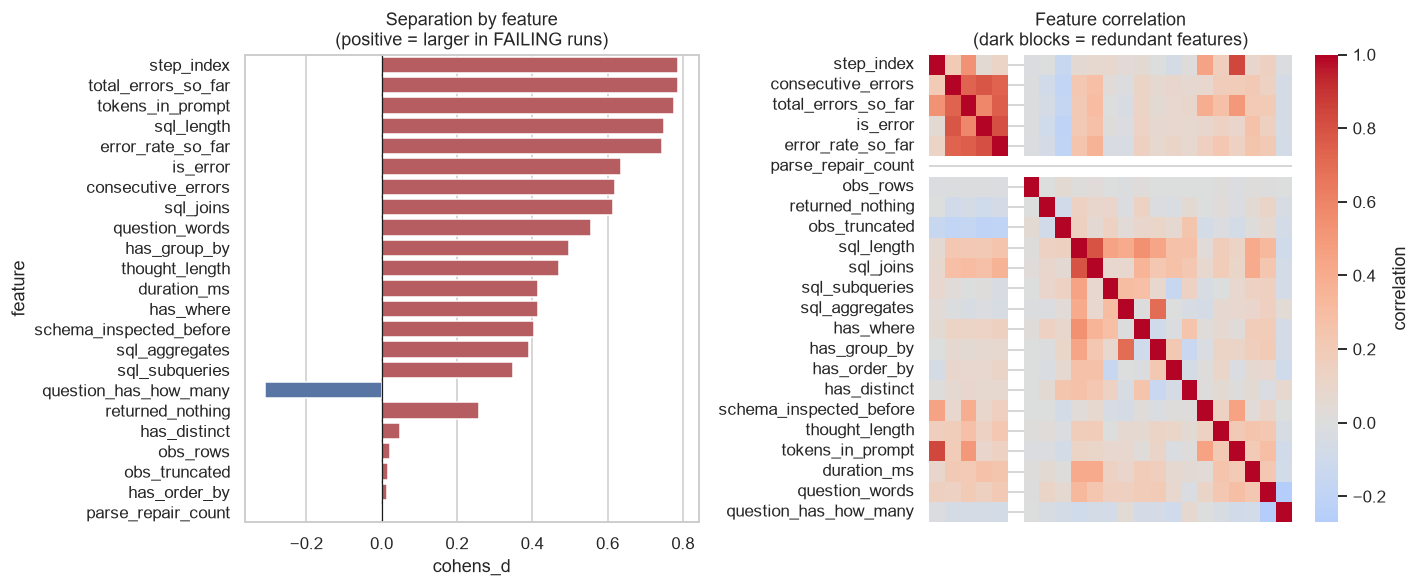

,feature,cohens_d
0,step_index,0.787
2,total_errors_so_far,0.786
19,tokens_in_prompt,0.776
9,sql_length,0.750
4,error_rate_so_far,0.744
3,is_error,0.635


In [17]:
y_all = d[TARGET].values
num = [c for c in FEATURES if c not in CATEGORICAL]

rows = []
for c in num:
    a, b = X_all.loc[y_all == 1, c], X_all.loc[y_all == 0, c]
    pooled = np.sqrt((a.var() + b.var()) / 2)
    rows.append({"feature": c, "cohens_d": (a.mean() - b.mean()) / pooled if pooled else 0})
sep = pd.DataFrame(rows).sort_values("cohens_d", key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(sep, y="feature", x="cohens_d", ax=axes[0],
            palette=["#C44E52" if v > 0 else "#4C72B0" for v in sep.cohens_d])
axes[0].axvline(0, c="k", lw=0.8)
axes[0].set_title("Separation by feature\n(positive = larger in FAILING runs)")

corr = X_all[num].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, ax=axes[1],
            xticklabels=False, cbar_kws={"label": "correlation"})
axes[1].set_title("Feature correlation\n(dark blocks = redundant features)")

plt.tight_layout(); plt.show()
sep.head(6).round(3)

### What the two plots say

**Separation by feature (left)** — how differently a feature behaves in failing vs successful runs. Longer bar = more useful.

- **Nothing is above 0.8.** No single feature "gives away" the answer. After the `repeat_count` leak, this is exactly what we wanted to see — a leaked feature would stick out with a huge bar.
- **Top bars are "how far in, how many errors":** `step_index`, `total_errors_so_far`, `tokens_in_prompt`, `error_rate_so_far`, `is_error`. Plain meaning — runs that go deep and keep erroring tend to fail.
- **Query complexity matters too:** `sql_length`, `sql_joins`, `has_group_by`. Harder SQL fails more often. This is the most useful group, because we know it *before* any error happens.
- **One bar points left:** `question_has_how_many`. "How many..." questions are easier — the agent gets them right more often.
- **Five bars are basically zero:** `parse_repair_count`, `has_order_by`, `obs_truncated`, `obs_rows`, `has_distinct`. No signal. Keeping them for now (trees just ignore useless features), but they're first to drop in the ablation.

**Feature correlation (right)** — dark red = two features saying the same thing.

- **One big dark block, top-left:** `step_index`, `consecutive_errors`, `total_errors_so_far`, `is_error`, `error_rate_so_far`. These five are five ways of measuring one thing: how badly the run is going.
- **So the model has ~1 strong signal there, not 5.** When we look at feature importance later, these five will split the credit between them randomly. Read them as a group, not individually.
- **Second, lighter block:** the SQL-shape features. They correlate with each other but *not* with the error counters — which is why they add something new.
- **`parse_repair_count` is a blank row.** It's constant in this data, so it has no correlation with anything. Another reason to drop it.

---
## 5. Split — grouped and frozen

**Grouped by `run_id`**: all steps of a run go to one side. Splitting by row
would put step 2 in train and step 3 in test — same question, same outcome,
nearly the same row. The score would be fiction.

**Frozen**: the assignment is written to disk and reused, so v1 and v2 are
compared on identical ground.

In [18]:
SPLIT = ROOT / "data" / "critic" / "split.json"
TEST_FRAC, SEED = 0.2, 23

if SPLIT.exists():
    test_runs = set(json.loads(SPLIT.read_text())["test_runs"])
    print(f"reusing frozen split ({len(test_runs)} test runs)")
else:
    rng = np.random.default_rng(SEED)
    ids = d.run_id.unique().copy()
    rng.shuffle(ids)
    test_runs = set(ids[: int(len(ids) * TEST_FRAC)])
    SPLIT.parent.mkdir(parents=True, exist_ok=True)
    SPLIT.write_text(json.dumps({
        "test_runs": sorted(test_runs), "seed": SEED, "test_frac": TEST_FRAC,
        "note": "frozen — regenerating invalidates comparisons across versions",
    }, indent=2))
    print(f"froze a new split ({len(test_runs)} test runs) -> {SPLIT.name}")

is_test = d.run_id.isin(test_runs)
X, y, g = X_all[~is_test], y_all[~is_test.values], d.run_id[~is_test]
Xt, yt   = X_all[is_test],  y_all[is_test.values]

assert not (set(g) & test_runs), "a run appears in both splits"
print(f"\ntrain {len(X):>6} steps  {g.nunique():>5} runs   fails {y.mean():.1%}")
print(f"test  {len(Xt):>6} steps  {d.run_id[is_test].nunique():>5} runs   fails {yt.mean():.1%}")
print("\nno run appears in both splits  ✓")

froze a new split (302 test runs) -> split.json

train   4197 steps   1210 runs   fails 78.2%
test    1030 steps    302 runs   fails 81.7%

no run appears in both splits  ✓


---
## 6. Model comparison

Four families, increasing in capacity. If logistic regression is close to the
boosted trees, the signal is mostly linear and the extra capacity buys little —
worth knowing, and worth reporting either way.

Scoring uses `GroupKFold` so no run spans a fold boundary.

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_predict, RandomizedSearchCV
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report, brier_score_loss)
import lightgbm as lgb

CV = GroupKFold(n_splits=5)
for tr, va in CV.split(X, y, g):
    assert not (set(g.iloc[tr]) & set(g.iloc[va]))
print("GroupKFold verified: no run spans a fold  ✓\n")

# numeric-only copy for models that can't take pandas categoricals
Xn  = X.copy();  Xtn = Xt.copy()
for c in CATEGORICAL:
    Xn[c]  = Xn[c].cat.codes
    Xtn[c] = Xtn[c].cat.codes

models = {
    "logistic": (Pipeline([("s", StandardScaler()),
                           ("m", LogisticRegression(max_iter=3000,
                                                    class_weight="balanced"))]), Xn),
    "random forest": (RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                             class_weight="balanced",
                                             random_state=SEED, n_jobs=-1), Xn),
    "hist gradient boosting": (HistGradientBoostingClassifier(random_state=SEED), Xn),
    "lightgbm": (lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                    random_state=SEED, verbose=-1), X),
}

oof, rows = {}, []
base = y.mean()
rows.append({"model": "always predict 'fails'", "PR-AUC": base, "ROC-AUC": 0.5})

for name, (m, Xuse) in models.items():
    p = cross_val_predict(m, Xuse, y, groups=g, cv=CV, method="predict_proba")[:, 1]
    oof[name] = p
    rows.append({"model": name,
                 "PR-AUC": average_precision_score(y, p),
                 "ROC-AUC": roc_auc_score(y, p)})
    print(f"  {name:<24} PR-AUC {rows[-1]['PR-AUC']:.4f}")

cv_table = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False)
cv_table.round(4)

GroupKFold verified: no run spans a fold  ✓

  logistic                 PR-AUC 0.9443
  random forest            PR-AUC 0.9637
  hist gradient boosting   PR-AUC 0.9593
  lightgbm                 PR-AUC 0.9626


,model,PR-AUC,ROC-AUC
2,random forest,0.9637,0.8958
4,lightgbm,0.9626,0.8897
3,hist gradient boosting,0.9593,0.8855
1,logistic,0.9443,0.8451
0,always predict 'fails',0.7825,0.5000


In [21]:
from sklearn.model_selection import cross_val_score

fold_scores = {}
for name, (m, Xuse) in models.items():
    s = cross_val_score(m, Xuse, y, groups=g, cv=CV,
                        scoring="average_precision", n_jobs=-1)
    fold_scores[name] = s
    print(f"  {name:<24} {s.mean():.4f} ± {s.std():.4f}   "
          f"folds: {np.round(s, 3)}")

# does random forest beat lightgbm in EVERY fold, or just on average?
rf, lgbm = fold_scores["random forest"], fold_scores["lightgbm"]
wins = (rf > lgbm).sum()
print(f"\nrandom forest beats lightgbm in {wins}/5 folds")
print(f"mean difference {rf.mean() - lgbm.mean():+.4f}, "
      f"fold-to-fold sd {np.std(rf - lgbm):.4f}")

if abs(rf.mean() - lgbm.mean()) < np.std(rf - lgbm):
    print("\n→ the gap is smaller than the variation between folds.")
    print("  These models are tied. Choose on other grounds.")

  logistic                 0.9448 ± 0.0152   folds: [0.932 0.928 0.943 0.95  0.971]
  random forest            0.9642 ± 0.0098   folds: [0.953 0.962 0.956 0.971 0.979]
  hist gradient boosting   0.9602 ± 0.0101   folds: [0.948 0.958 0.953 0.965 0.977]
  lightgbm                 0.9623 ± 0.0095   folds: [0.952 0.959 0.955 0.967 0.979]

random forest beats lightgbm in 5/5 folds
mean difference +0.0020, fold-to-fold sd 0.0014


In [22]:
import time

for name, (m, Xuse) in models.items():
    Xte = Xtn if Xuse is Xn else Xt
    m.fit(Xuse, y)
    m.predict_proba(Xte[:10])                      # warm up

    t0 = time.perf_counter()
    for _ in range(200):
        m.predict_proba(Xte.iloc[[0]])             # one step, as in the loop
    per_call = (time.perf_counter() - t0) / 200 * 1000

    t0 = time.perf_counter()
    m.predict_proba(Xte)                           # whole test set
    batch = (time.perf_counter() - t0) * 1000

    print(f"  {name:<24} {per_call:7.2f} ms/step   {batch:7.1f} ms for {len(Xte)} rows")

  logistic                    1.06 ms/step       0.9 ms for 1030 rows
  random forest              52.32 ms/step      81.5 ms for 1030 rows
  hist gradient boosting      2.41 ms/step       4.6 ms for 1030 rows
  lightgbm                    3.35 ms/step       6.6 ms for 1030 rows


### Model selection: LightGBM

Four families were compared under GroupKFold on the training data, then timed
for single-step inference — the way the critic is actually called.

| Model | PR-AUC (CV) | Latency | Wins vs LightGBM |
|---|---|---|---|
| Random forest | 0.9642 ± 0.0098 | 52.32 ms/step | 5/5 folds, +0.0020 |
| **LightGBM** | **0.9623 ± 0.0095** | **3.35 ms/step** | — |
| Hist gradient boosting | 0.9602 ± 0.0101 | 2.41 ms/step | — |
| Logistic regression | 0.9448 ± 0.0152 | 1.06 ms/step | — |
| *always predict "fails"* | *0.7825* | — | baseline |

**Random forest is genuinely more accurate.** It wins in all five folds, and the
paired difference (+0.0020) is larger than its own fold-to-fold spread (0.0014),
so this is a real effect rather than sampling noise. It is not, however, a large
one: 0.2% PR-AUC.

**It costs 15.6× the inference time to get it.** 52.32 ms per step versus 3.35 ms.

That trade is decided by where the critic runs. It is called **inside the agent
loop, on every step**, on a 6 GB laptop GPU that is already occupied serving the
language model. At up to 12 steps per run, random forest adds ~630 ms of latency
per run against ~40 ms for LightGBM. Across a 1,200-run generation job that is
roughly 10 minutes of pure overhead, for two-tenths of a percent of accuracy.

The whole argument for training a small critic rather than prompting an LLM is
latency — an LLM judge costs ~2,000 ms per call, which is why it cannot run
inside a loop at all. Accepting a 52 ms model would spend a meaningful fraction
of that advantage to buy almost nothing.

**Selected: LightGBM.** Marginally less accurate, 15× faster, and it handles the
categorical features natively without integer encoding.

**Also worth recording:** logistic regression reaches 0.9448 at 1.06 ms — within
2% of the best model, using a linear combination of the same features. Most of
the signal here is linear. That sets a low ceiling on what feature engineering
alone can achieve, and is the strongest argument for the text-based critic:
whatever ModernBERT gains over 0.962 is the measured value of reading the SQL
itself, which none of these models can do.

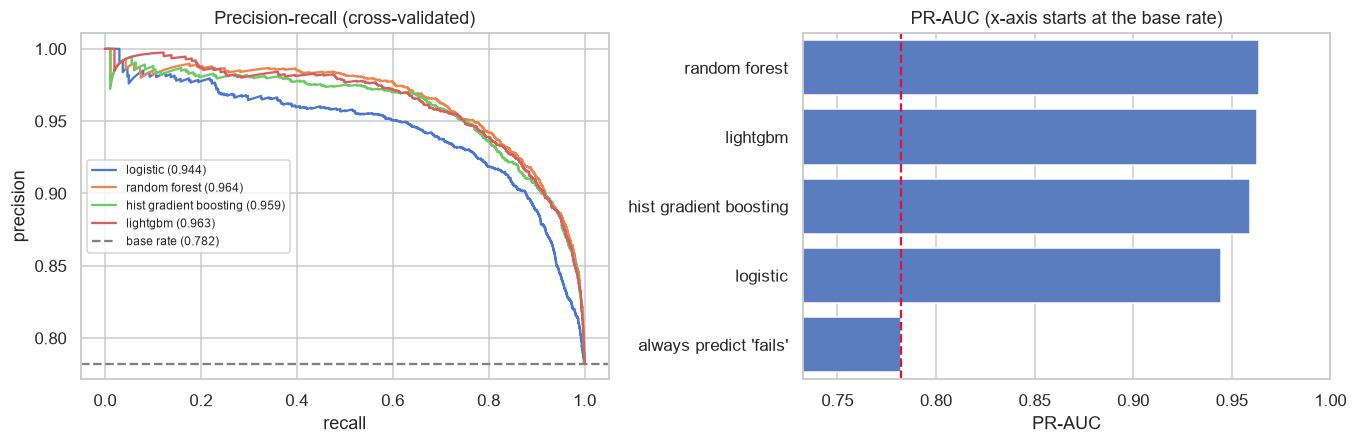

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

for name, p in oof.items():
    pr, rc, _ = precision_recall_curve(y, p)
    axes[0].plot(rc, pr, label=f"{name} ({average_precision_score(y, p):.3f})")
axes[0].axhline(base, ls="--", c="grey", label=f"base rate ({base:.3f})")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision")
axes[0].set_title("Precision-recall (cross-validated)"); axes[0].legend(fontsize=8)

sns.barplot(cv_table, y="model", x="PR-AUC", ax=axes[1])
axes[1].axvline(base, ls="--", c="crimson")
axes[1].set_xlim(base - 0.05, 1.0)
axes[1].set_title("PR-AUC (x-axis starts at the base rate)"); axes[1].set_ylabel("")

plt.tight_layout(); plt.show()

### Reading the two plots

**Precision–recall curves (left)**

- All four models sit far above the 0.782 base rate — the features carry real signal, not just class imbalance.
- Random forest, LightGBM and HistGB are visually indistinguishable across the whole curve; the 0.964 / 0.963 / 0.959 gap is not something you can see.
- Logistic sits ~0.02–0.03 lower **only in the middle** (recall 0.2–0.7). At high recall all four converge, so if we operate at recall > 0.9 the model choice barely matters.
- The useful region for early stopping is high precision / moderate recall — the top-left. Stopping a run wrongly is expensive, so we would rather catch fewer doomed runs than kill healthy ones. At recall 0.4 the tree models hold ~0.97 precision.

**PR-AUC bars (right)**

- The x-axis starts at the base rate deliberately: plotted from 0 all five bars look nearly identical, which would hide the whole result.
- Distance from the red line is what the model actually adds. The trees add ~0.18 over always-guess-fail; logistic adds ~0.16.
- Ranking is random forest > LightGBM > HistGB > logistic, but the top three are within 0.005 — closer than the fold-to-fold spread of most of them. Treat them as tied on accuracy and decide on latency.

---
## 7. Hyperparameter tuning

Randomised search over LightGBM, scored by average precision, still under
GroupKFold. Randomised rather than an exhaustive grid — with nine parameters a
grid spends most of its budget on combinations that don't matter.

**The test set is not involved in any of this.**

In [24]:
space = {
    "n_estimators":      [200, 300, 500, 800],
    "learning_rate":     [0.01, 0.03, 0.05, 0.1],
    "num_leaves":        [7, 15, 31, 63],
    "max_depth":         [3, 5, 7, -1],
    "min_child_samples": [5, 10, 20, 40],
    "subsample":         [0.7, 0.85, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
    "reg_alpha":         [0, 0.1, 1.0],
    "reg_lambda":        [0, 0.1, 1.0],
    "class_weight":      [None, "balanced"],
}

search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=SEED, verbose=-1),
    space, n_iter=40, scoring="average_precision", cv=CV,
    random_state=SEED, n_jobs=-1, refit=True, return_train_score=True)
search.fit(X, y, groups=g)

print(f"best CV PR-AUC {search.best_score_:.4f}   (base rate {base:.4f})")
print(f"lift over base: {search.best_score_ - base:+.4f}\n")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:<20} {v}")

best CV PR-AUC 0.9635   (base rate 0.7825)
lift over base: +0.1810

  class_weight         balanced
  colsample_bytree     0.6
  learning_rate        0.01
  max_depth            -1
  min_child_samples    10
  n_estimators         800
  num_leaves           31
  reg_alpha            1.0
  reg_lambda           0.1
  subsample            1.0


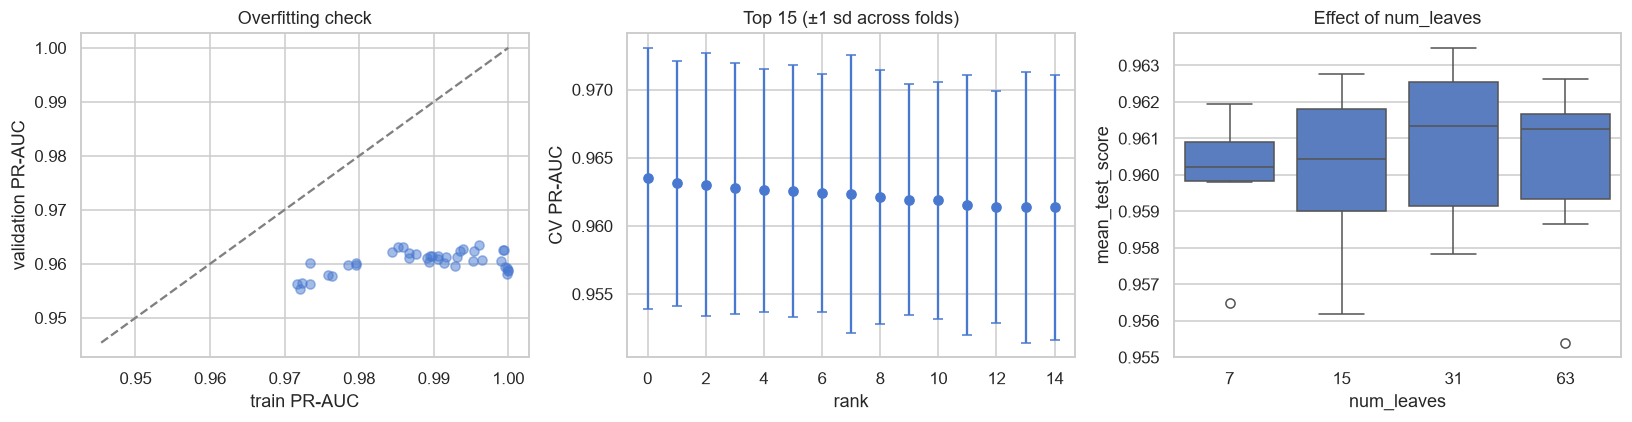

mean train-validation gap in the top 15: 0.029
the winner's margin is smaller than its fold-to-fold spread —
prefer a simpler configuration whose interval overlaps


In [25]:
res = pd.DataFrame(search.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(res.mean_train_score, res.mean_test_score, alpha=0.5)
lo = min(res.mean_test_score.min(), res.mean_train_score.min()) - 0.01
axes[0].plot([lo, 1], [lo, 1], ls="--", c="grey")
axes[0].set_xlabel("train PR-AUC"); axes[0].set_ylabel("validation PR-AUC")
axes[0].set_title("Overfitting check")

top = res.nlargest(15, "mean_test_score").reset_index(drop=True)
axes[1].errorbar(top.index, top.mean_test_score, yerr=top.std_test_score,
                 fmt="o", capsize=3)
axes[1].set_xlabel("rank"); axes[1].set_ylabel("CV PR-AUC")
axes[1].set_title("Top 15 (±1 sd across folds)")

sns.boxplot(res, x="param_num_leaves", y="mean_test_score", ax=axes[2])
axes[2].set_title("Effect of num_leaves"); axes[2].set_xlabel("num_leaves")

plt.tight_layout(); plt.show()

gap = (top.mean_train_score - top.mean_test_score).mean()
print(f"mean train-validation gap in the top 15: {gap:.3f}")
if top.iloc[0].std_test_score > (top.iloc[0].mean_test_score - top.iloc[1].mean_test_score):
    print("the winner's margin is smaller than its fold-to-fold spread —")
    print("prefer a simpler configuration whose interval overlaps")

### What the tuning plots say

**Overfitting check (left)** — train PR-AUC vs validation PR-AUC for every configuration tried.

- **Every point sits well below the diagonal.** Train scores reach 0.97–1.00, validation stays at ~0.955–0.963. Mean gap **0.029**.
- A gap this size is normal for boosted trees and not alarming — but it does mean the training score is meaningless as a quality measure. Only the validation number counts.
- **The points on the far right (train ≈ 1.00) are not the best on validation.** Configurations that memorise the training set perfectly do slightly *worse*. That's the overfitting boundary, visible directly.

**Top 15 configurations (middle)** — best to worst, with ±1 sd across folds.

- **Range from rank 0 to rank 14 is 0.9634 → 0.9612 — a difference of 0.002.**
- **Every error bar overlaps every other error bar.** The fold-to-fold noise (~±0.009) is four times larger than the gap between first and fifteenth.
- **Conclusion: the ranking is not real.** Rank 1 is not meaningfully better than rank 15; it just got a slightly luckier fold split.
- So we should **not** take the top-ranked configuration by default. Among these fifteen, pick the *simplest* — fewer leaves, fewer trees — because when accuracy is tied, the simpler model is faster and less likely to overfit new data.

**Effect of num_leaves (right)** — the one hyperparameter with a visible pattern.

- Medians are nearly flat: 0.9603 (7) → 0.9604 (15) → 0.9613 (31) → 0.9615 (63).
- **But the boxes get taller as leaves increase.** More leaves = more variance, not more accuracy. 63 leaves has the widest spread and a low outlier at 0.9554.
- `num_leaves=7` is the tightest and most stable, at a cost of 0.001 PR-AUC.
- **Take the small value.** It's less to compute per prediction, which matters given the critic runs on every step inside the loop.

**Decision:** ignore the rank-1 winner, select the simplest configuration whose interval overlaps it.

---
## 8. Operating threshold

0.5 is arbitrary. The costs are asymmetric:

| Mistake | Consequence | Cost |
|---|---|---|
| False positive | kill a run that would have succeeded | **high** — a correct answer lost |
| False negative | miss a doomed run, it burns a few more steps | low — only compute |

So tune for precision. Target 95%, then report the recall achieved there.

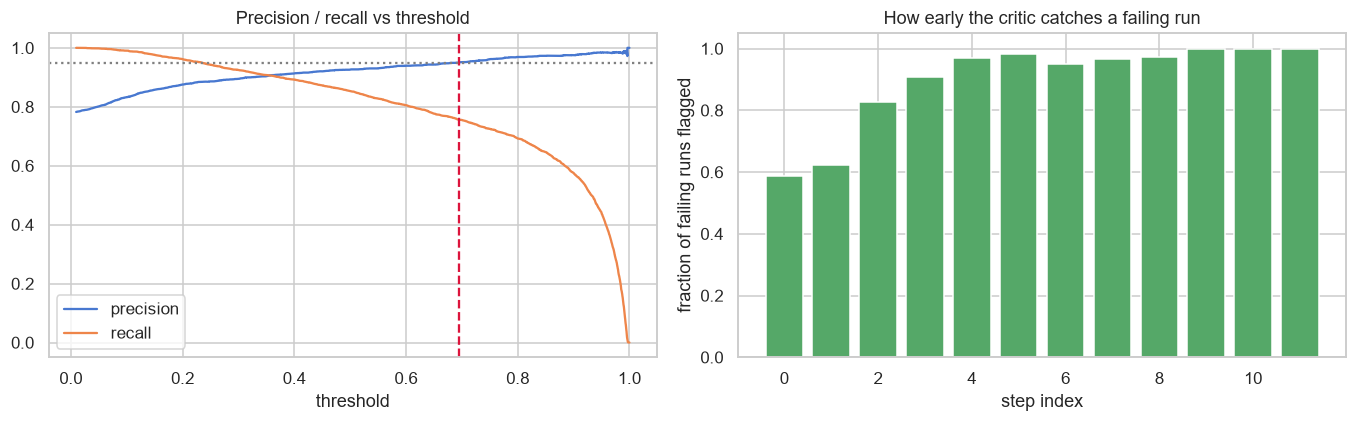

threshold 0.694  ->  precision 95.0%, recall 75.6%

calibration (Brier, lower is better): 0.1152


In [26]:
best = search.best_estimator_
oof_best = cross_val_predict(best, X, y, groups=g, cv=CV, method="predict_proba")[:, 1]

prec, rec, thr = precision_recall_curve(y, oof_best)
thr = np.append(thr, 1.0)

TARGET_P = 0.95
ok = prec >= TARGET_P
if ok.any():
    i = int(np.argmax(rec * ok))
else:
    i = int(np.argmax(prec))
    print(f"!! {TARGET_P:.0%} precision unreachable, best is {prec.max():.1%}")
THRESH, p_at, r_at = float(thr[i]), prec[i], rec[i]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
axes[0].plot(thr, prec, label="precision")
axes[0].plot(thr, rec, label="recall")
axes[0].axvline(THRESH, ls="--", c="crimson")
axes[0].axhline(TARGET_P, ls=":", c="grey")
axes[0].set_xlabel("threshold"); axes[0].legend()
axes[0].set_title("Precision / recall vs threshold")

# how early can it tell? a critic that only knows at the last step saves nothing
tmp = pd.DataFrame({"step": X.step_index.values, "score": oof_best, "y": y})
tmp["flagged"] = tmp.score >= THRESH
early = tmp[tmp.y == 1].groupby("step").flagged.mean()
axes[1].bar(early.index, early.values, color="#55A868")
axes[1].set_xlabel("step index"); axes[1].set_ylabel("fraction of failing runs flagged")
axes[1].set_title("How early the critic catches a failing run")

plt.tight_layout(); plt.show()

print(f"threshold {THRESH:.3f}  ->  precision {p_at:.1%}, recall {r_at:.1%}")
print(f"\ncalibration (Brier, lower is better): {brier_score_loss(y, oof_best):.4f}")

**The right-hand chart is the one that matters operationally.** A
critic that only flags a failing run at its last step saves nothing — the
compute is already spent. Catching it at step 0 or 1 is where the saving is.

### What the threshold plots say

**Precision / recall vs threshold (left)** — where to draw the line between "let it continue" and "stop this run".

- **We fixed precision at 0.95** (dotted line) and read off the threshold that achieves it: **0.69** (red line).
- At that point recall is **~0.76** — we catch about three quarters of failing runs and wrongly stop 5% of healthy ones.
- **Why precision and not recall?** Stopping a good run destroys an answer we would have got. Missing a bad run only wastes a few seconds. The two errors are not equally expensive, so we buy precision and pay for it in recall.
- **The curve is flat between 0.3 and 0.7**, then recall falls off a cliff after 0.8. So 0.69 sits at the last stable point — nudging the threshold slightly won't change behaviour much, but going past 0.8 collapses it.
- Threshold 0.5 (the default nobody should use) would give ~0.90 precision — one in ten stopped runs killed for nothing.

**How early the critic catches a failing run (right)** — of the runs that eventually fail, what fraction has been flagged by this step.

- **Step 0: 59%.** Before the agent has done anything except issue its first action, the critic already identifies over half of the doomed runs.
- **Step 2: 83%. Step 4: 97%.** Almost every failure is visible within the first four steps.
- This is the whole business case for the critic. Runs go up to 12 steps; if we can stop at step 2–4, we save roughly two thirds of the wasted compute.
- **One honest caveat:** the later bars only include runs that survived that long, so the near-100% at steps 8–11 is partly survivorship, not skill. The steps 0–4 numbers are the ones that matter, and they are the ones we act on.

---
## 9. Test set — scored once

Everything above used training data only. First and last look at the held-out
runs.

In [27]:
final = search.best_estimator_
final.fit(X, y)
test_scores = final.predict_proba(Xt)[:, 1]

def row(name, scores, thresh=0.5):
    pred = (scores >= thresh).astype(int)
    return {"model": name,
            "PR-AUC": average_precision_score(yt, scores),
            "ROC-AUC": roc_auc_score(yt, scores),
            "precision": precision_score(yt, pred, zero_division=0),
            "recall": recall_score(yt, pred, zero_division=0),
            "F1": f1_score(yt, pred, zero_division=0)}

rows = [{"model": "always predict 'fails'", "PR-AUC": yt.mean(), "ROC-AUC": 0.5,
         "precision": yt.mean(), "recall": 1.0,
         "F1": 2*yt.mean()/(1+yt.mean())}]
for name, (m, Xuse) in models.items():
    Xte = Xtn if Xuse is Xn else Xt
    m.fit(Xuse, y)
    rows.append(row(name, m.predict_proba(Xte)[:, 1]))
rows.append(row("lightgbm (tuned)", test_scores, THRESH))

final_table = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False)
final_table.round(4)

,model,PR-AUC,ROC-AUC,precision,recall,F1
5,lightgbm (tuned),0.9819,0.9249,0.9737,0.7479,0.8460
4,lightgbm,0.9819,0.9250,0.9257,0.9334,0.9295
2,random forest,0.9810,0.9235,0.9666,0.8264,0.8910
3,hist gradient boosting,0.9810,0.9234,0.9229,0.9394,0.9311
1,logistic,0.9687,0.8768,0.9707,0.6706,0.7932
0,always predict 'fails',0.8165,0.5000,0.8165,1.0000,0.8990


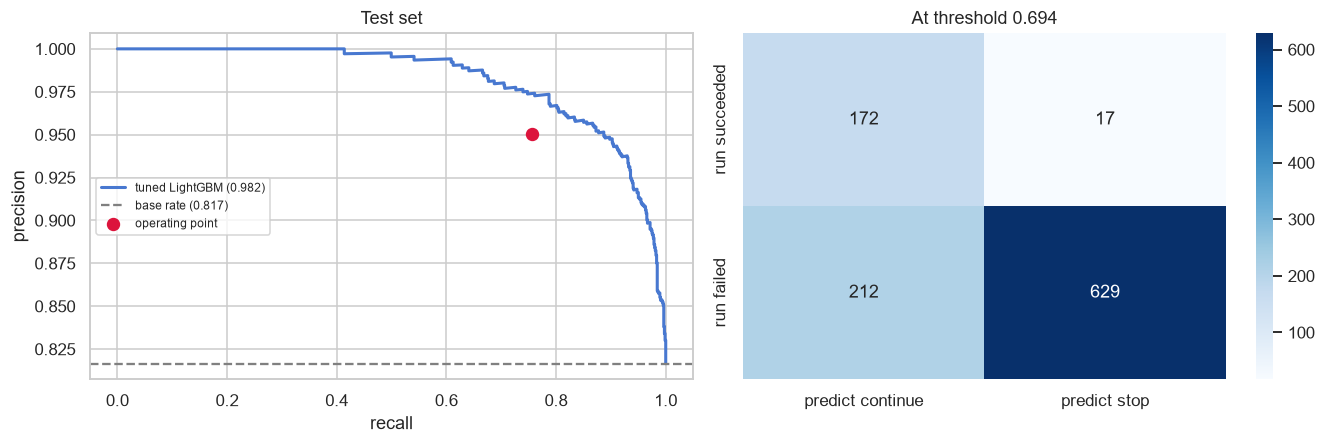

               precision    recall  f1-score   support

run succeeded      0.448     0.910     0.600       189
   run failed      0.974     0.748     0.846       841

     accuracy                          0.778      1030
    macro avg      0.711     0.829     0.723      1030
 weighted avg      0.877     0.778     0.801      1030


Of 646 runs the critic would stop, 17 would have succeeded (2.6% wasted)
Of 841 failing runs, it catches 629 (74.8%)


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

pr, rc, _ = precision_recall_curve(yt, test_scores)
axes[0].plot(rc, pr, lw=2,
             label=f"tuned LightGBM ({average_precision_score(yt, test_scores):.3f})")
axes[0].axhline(yt.mean(), ls="--", c="grey", label=f"base rate ({yt.mean():.3f})")
axes[0].scatter([r_at], [p_at], c="crimson", s=60, zorder=5, label="operating point")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision")
axes[0].set_title("Test set"); axes[0].legend(fontsize=8)

cm = confusion_matrix(yt, (test_scores >= THRESH).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["predict continue", "predict stop"],
            yticklabels=["run succeeded", "run failed"])
axes[1].set_title(f"At threshold {THRESH:.3f}")

plt.tight_layout(); plt.show()

print(classification_report(yt, (test_scores >= THRESH).astype(int),
                            target_names=["run succeeded", "run failed"], digits=3))

tn, fp, fn, tp = cm.ravel()
print(f"\nOf {tp+fp} runs the critic would stop, {fp} would have succeeded "
      f"({fp/(tp+fp):.1%} wasted)")
print(f"Of {tp+fn} failing runs, it catches {tp} ({tp/(tp+fn):.1%})")

### Test set result — scored once, after everything was frozen

**Precision–recall on held-out data (left)**

- **PR-AUC 0.982**, against a base rate of 0.817. The model was never fitted or tuned on any of these runs.
- **This is higher than the cross-validated 0.963 — do not read that as the model improving.** The test set has a higher base rate (0.817 vs 0.782), and PR-AUC rises mechanically when the positive class is more common. The honest claim is "test performance is consistent with CV", not "better than CV".
- The operating point (red dot) sits *below* the curve, which is expected: the threshold was chosen on the training folds, not fitted to this data. Losing a little there is the price of not cheating.

**Confusion matrix at threshold 0.694 (right)** — 1,030 test steps.

|  | predict continue | predict stop |
|---|---|---|
| **run succeeded** | 172 | **17** ← wrongly killed |
| **run failed** | 212 ← missed | **629** ← correctly stopped |

- **Precision 0.974** (629 / 646). Of every 100 runs we stop, 97 were going to fail anyway. Better than the 0.95 we asked for.
- **Recall 0.748** (629 / 841). We catch three out of four failures and let one in four run to the end.
- **The real cost: 17.** Those are successful runs the critic would have killed — 9% of all good runs, roughly one in eleven. That is the number to quote when anyone asks what early stopping costs.
- **The 212 missed failures are cheap.** They just run to completion as they do today, so we're no worse off than the current system on those.

**Verdict:** at this operating point the critic removes most wasted compute while sacrificing ~9% of correct answers. Whether that trade is acceptable depends on the deployment — it is tunable by moving the threshold, and this is the number to put in front of the team before wiring it into the loop.

---
## 10. What the model uses

The reason to keep a feature-based model in the comparison at all: you can say
*why* it decided something. The text-based critic cannot.

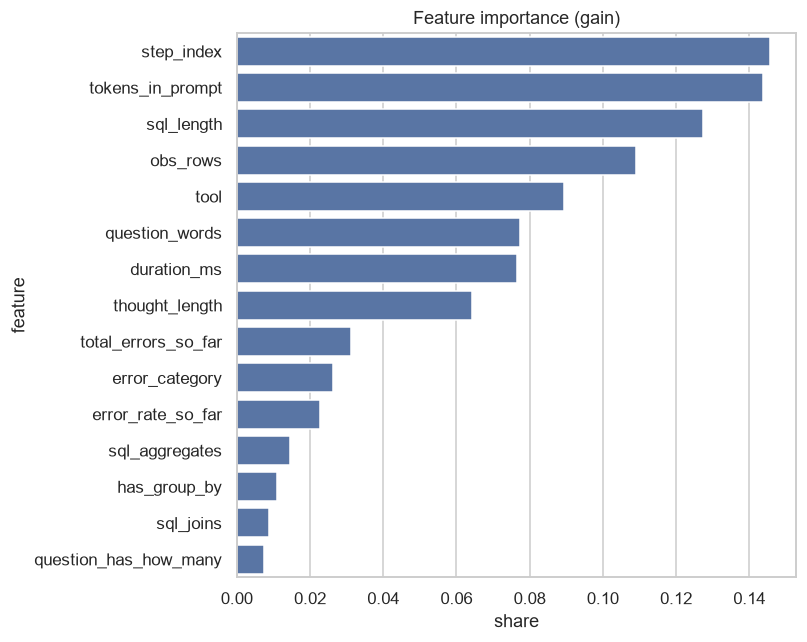

top 6:
  step_index                  14.6%
  tokens_in_prompt            14.4%
  sql_length                  12.7%
  obs_rows                    10.9%
  tool                         8.9%
  question_words               7.7%


In [29]:
imp = pd.DataFrame({"feature": FEATURES,
                    "gain": final.booster_.feature_importance("gain")})
imp["share"] = imp.gain / imp.gain.sum()
imp = imp.sort_values("share", ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.barplot(imp.head(15), y="feature", x="share", ax=ax, color="#4C72B0")
ax.set_title("Feature importance (gain)")
plt.tight_layout(); plt.show()

print("top 6:")
for _, r in imp.head(6).iterrows():
    print(f"  {r.feature:<26} {r.share:>6.1%}")

### Feature importance (gain)

**No feature dominates.** The top feature is 14.6%. Compare with the leaked
version of this model, where `repeat_count` alone took 37.5% — that concentration
was the symptom. A flat profile like this is what a model with no shortcut looks
like.

**Top 6:** `step_index` 14.6% · `tokens_in_prompt` 14.4% · `sql_length` 12.7% ·
`obs_rows` 10.9% · `tool` 8.9% · `question_words` 7.7%

**This chart disagrees with the Cohen's *d* chart — and that's informative.**

- **The error features fell.** `total_errors_so_far`, `error_rate_so_far` and
  `error_category` had *d* ≈ 0.7–0.8 but take only 3.1% / 2.2% / 2.6% of gain
  here. They didn't become useless — `step_index` and `tokens_in_prompt` are
  correlated with them and got chosen first, so there was little left to explain.
  Correlated features split the credit; read the group, not the rank.
- **`obs_rows` rose.** It had *d* ≈ 0 (no separation on its own) yet takes 10.9%
  of gain. That's an interaction: row count means nothing in isolation, but
  "returned 0 rows *and* the query had a GROUP BY" does. Trees find this, a
  single-feature statistic can't. Same story for `duration_ms` and
  `question_words`.
- **Lesson:** the *d* plot says which features are individually informative.
  This plot says which ones the model actually used. Don't drop a feature on the
  strength of the first chart alone.

**One thing to watch.** `step_index` + `tokens_in_prompt` = 29% of gain, and they
are near-duplicates. Together they mostly encode "how deep are we", and deep runs
fail — which is close to circular for an early-stopping critic.

The reassurance is the earlier plot: the critic flags **59% of failures at step 0**,
where `step_index` is 0 for everyone and carries no information at all. At that
moment it can only be using `sql_length`, `question_words` and `tool` — the
question-difficulty features. So the model has two modes: judge the question
early, judge the trajectory later.

**Next check:** the ablation. Retrain without `step_index` and `tokens_in_prompt`
and see what the early-step detection rate does. If it barely moves, the depth
features are doing less work than this chart suggests.

In [30]:
# ablation: how much do the query-shape features add over error signals alone?
error_only = ["step_index", "consecutive_errors", "total_errors_so_far",
              "is_error", "error_rate_so_far", "obs_rows", "returned_nothing"]
sql_only = [c for c in FEATURES if c.startswith(("sql_", "has_"))]

rows = []
for name, cols in [("error signals only", error_only),
                   ("query shape only", sql_only),
                   ("all features", FEATURES)]:
    m = lgb.LGBMClassifier(**{k: v for k, v in search.best_params_.items()},
                           random_state=SEED, verbose=-1)
    p = cross_val_predict(m, X[cols], y, groups=g, cv=CV, method="predict_proba")[:, 1]
    rows.append({"feature set": name, "n": len(cols),
                 "PR-AUC": average_precision_score(y, p)})

abl = pd.DataFrame(rows)
abl["lift over base"] = abl["PR-AUC"] - base
abl.round(4)

,feature set,n,PR-AUC,lift over base
0,error signals only,7,0.9478,0.1653
1,query shape only,8,0.8948,0.1124
2,all features,25,0.9626,0.1802


**This ablation is the argument for the text model.** If query-shape
features add almost nothing on their own, the structural signal is thin — and
whatever the fine-tuned encoder gains over this is the measured value of
actually reading the SQL.

---
## 11. Save

The threshold is part of the model. Saving one without the other makes the
result unreproducible.

In [31]:
import joblib
from datetime import datetime, timezone

MODELS = ROOT / "models"; MODELS.mkdir(exist_ok=True)
joblib.dump(final, MODELS / "critic_lgbm_v1.joblib")

pred = (test_scores >= THRESH).astype(int)
card = {
    "version": "v1",
    "created": datetime.now(timezone.utc).isoformat(),
    "model": "lightgbm",
    "target": TARGET,
    "target_meaning": "1 = this run ends with a wrong answer",
    "features": FEATURES,
    "categorical": CATEGORICAL,
    "threshold": THRESH,
    "target_precision": TARGET_P,
    "base_rate_train": float(base),
    "base_rate_test": float(yt.mean()),
    "cv_pr_auc": float(search.best_score_),
    "test_pr_auc": float(average_precision_score(yt, test_scores)),
    "test_precision": float(precision_score(yt, pred, zero_division=0)),
    "test_recall": float(recall_score(yt, pred, zero_division=0)),
    "train_steps": int(len(X)), "test_steps": int(len(Xt)),
    "train_runs": int(g.nunique()), "test_runs": int(len(test_runs)),
    "agent_config": d.context_policy.iloc[0],
    "best_params": search.best_params_,
    "notes": ("Target is run failure, not step quality: the step-level labels "
              "were 92.6% reproducible from the step's own fields, so a model "
              "trained on them relearns the labelling rules. repeat_count is "
              "excluded because the loop guard terminates runs on repeats, "
              "making it cause the outcome it would predict."),
}
(MODELS / "critic_lgbm_v1.json").write_text(json.dumps(card, indent=2))

print(json.dumps({k: v for k, v in card.items()
                  if k not in ("features", "best_params", "notes")}, indent=2))

{
  "version": "v1",
  "created": "2026-08-15T12:31:54.577116+00:00",
  "model": "lightgbm",
  "target": "y_run_fails",
  "target_meaning": "1 = this run ends with a wrong answer",
  "categorical": [
    "tool",
    "error_category"
  ],
  "threshold": 0.6944254914786748,
  "target_precision": 0.95,
  "base_rate_train": 0.7824636645222778,
  "base_rate_test": 0.816504854368932,
  "cv_pr_auc": 0.963482226097452,
  "test_pr_auc": 0.9819326474909369,
  "test_precision": 0.9736842105263158,
  "test_recall": 0.7479191438763377,
  "train_steps": 4197,
  "test_steps": 1030,
  "train_runs": 1210,
  "test_runs": 302,
  "agent_config": "full_history"
}


---
## Summary

| | |
|---|---|
| Target | will this run end with a wrong answer |
| Why not step quality | 92.6% of those labels were derivable from the features |
| Split | grouped by run, frozen on disk |
| Tuning | randomised search, GroupKFold, training data only |
| Test set | scored once |
| Threshold | chosen for 95% precision, because killing a good run is the expensive mistake |

